In [4]:
for i in range(5, 9):
    print(i)

5
6
7
8


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [6]:
img = cv2.imread('./image1.jpg')
if img is None:
    print("no image loaded...")

In [7]:
img = cv2.resize(img, (250, 250))
print("Data type: ", type(img))
print("Shape: ", img.shape)
print("Dtype: ", img.dtype)
print(f"Height = {img.shape[0]} pixel")
print(f"Width = {img.shape[1]} pixel")
print(f"Channel = {img.shape[2]} (BGR)")

img_RGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Data type:  <class 'numpy.ndarray'>
Shape:  (250, 250, 3)
Dtype:  uint8
Height = 250 pixel
Width = 250 pixel
Channel = 3 (BGR)


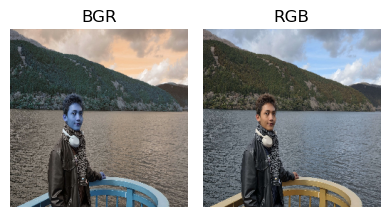

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(4, 6))
axes[0].imshow(img)
axes[0].set_title('BGR')
axes[1].imshow(img_RGB)
axes[1].set_title('RGB')
axes[0].axis('off')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [32]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
res_to_crop = 10
img_crop = img_gray[60:60+res_to_crop, 160:160+res_to_crop]
img_crop_rgb = img_RGB[60:60+res_to_crop, 160:160+res_to_crop]

print(img_crop)

[[200 199 197 198 198 198 197 198 198 198]
 [199 200 199 200 198 198 198 198 198 198]
 [201 201 201 202 201 202 201 200 200 200]
 [199 209 206 207 204 203 203 202 203 207]
 [ 89 127 179 183 213 213 213 214 214 214]
 [ 63  77  77  89 197 200 208 219 219 219]
 [ 71  81  86  75  90 134 209 227 224 221]
 [ 70  82  76  63  67  70  84  97 213 229]
 [ 71  74  76  68  79  74  79  74  86 112]
 [ 74  74  72  63  60  78  68  66  82  77]]


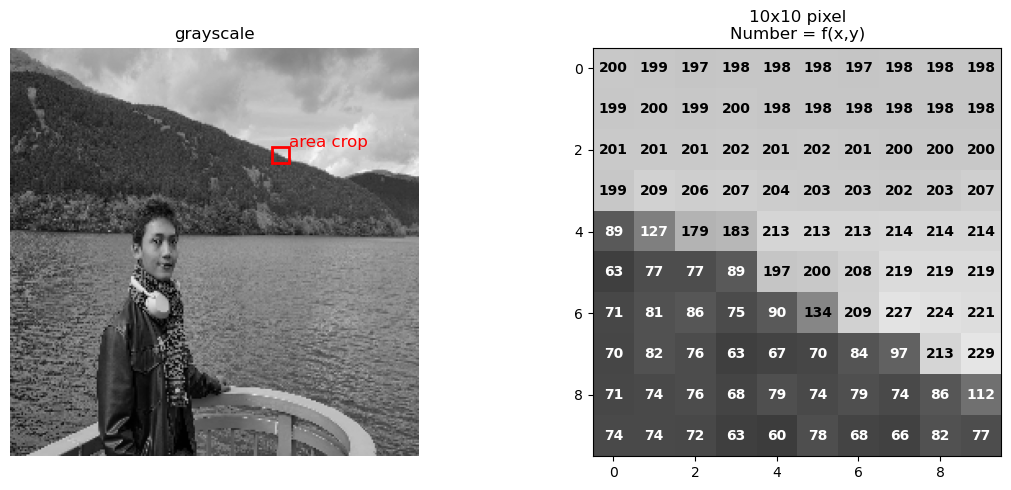

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('grayscale')
axes[0].axis('off')
rect = patches.Rectangle((160, 60), res_to_crop, res_to_crop, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(170, 60, 'area crop', color='red', fontsize=12)

axes[1].imshow(img_crop, cmap='gray', vmin=0, vmax=255)
for i in range(res_to_crop):
    for j in range(res_to_crop):
        nilai = img_crop[i, j]
        text_color = 'white' if nilai < 128 else 'black'
        axes[1].text(j, i, str(nilai), ha='center', va='center',
                     fontsize=10, color=text_color, fontweight='bold')
axes[1].set_title('10x10 pixel\nNumber = f(x,y)')
# axes[1].axis('off')
plt.tight_layout()
plt.show()

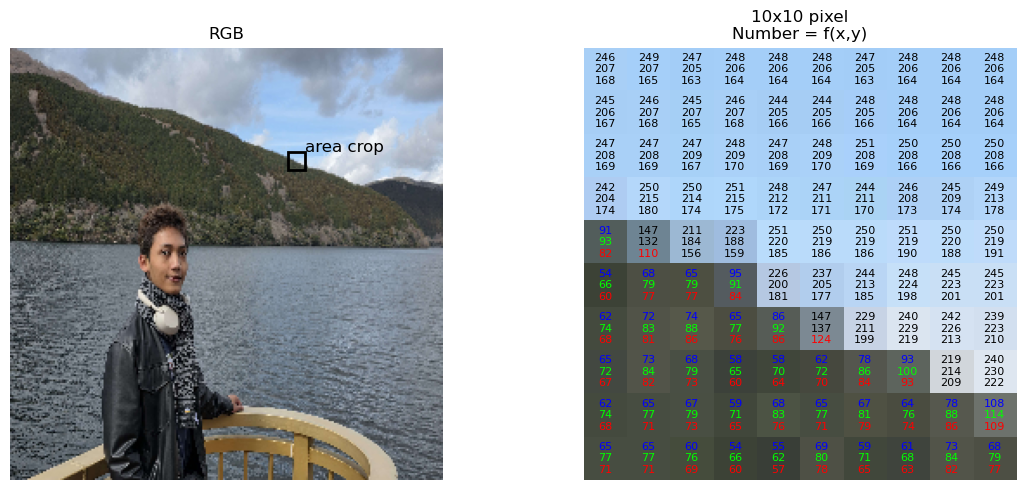

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_RGB)
axes[0].set_title('RGB')
axes[0].axis('off')
rect = patches.Rectangle((160, 60), res_to_crop, res_to_crop, linewidth=2, edgecolor='black', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(170, 60, 'area crop', color='black', fontsize=12)
offset = -0.15;
axes[1].imshow(img_crop_rgb)
for i in range(res_to_crop):
    for j in range(res_to_crop):
        (r, g, b) = img_crop_rgb[i, j]
        axes[1].text(j, i-offset, str(r), ha='center', va='top',
                     fontsize=8, color=(abs(round(r/255)-1), 0, 0))
        axes[1].text(j, i, str(g), ha='center', va='center',
                     fontsize=8, color=(0, abs(round(g/255)-1), 0))
        axes[1].text(j, i+offset, str(b), ha='center', va='bottom',
                     fontsize=8, color=(0, 0, abs(round(b/255)-1)))
axes[1].set_title('10x10 pixel\nNumber = f(x,y)')
axes[1].axis('off')
plt.tight_layout()
plt.show()